# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

from scipy.stats import zscore

# Load Dataset

In [2]:
df = pd.read_csv(
    "train.csv"
)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Convert Dates

In [3]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)


df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=True
)

# Create Weekly Sales

In [4]:
weekly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )
    ["Sales"]
    .sum()
    .reset_index()
)


weekly_sales.columns = [
    "Date",
    "Sales"
]


weekly_sales.head()

,Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


# Visualize Normal Sales Pattern

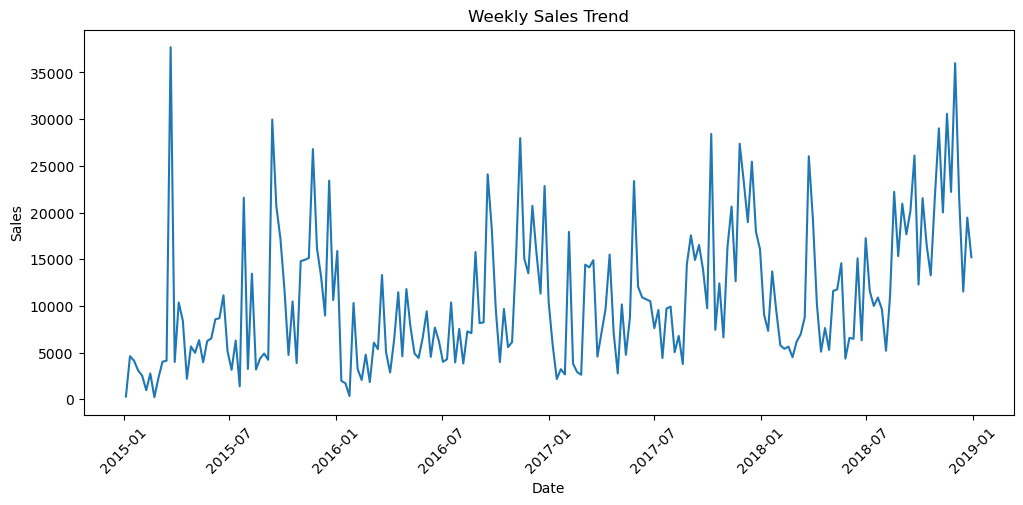

In [5]:
plt.figure(figsize=(12,5))


plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"]
)


plt.title(
    "Weekly Sales Trend"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Sales"
)


plt.xticks(rotation=45)
plt.savefig("charts/Weekly Sales Trend.png")
plt.show()

## his gives a baseline.

We visually understand:

. normal sales movement
. sudden spikes
. sudden drop

# Isolation Forest

## train Isolation Forest

In [6]:
X = weekly_sales[
    ["Sales"]
]

In [7]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

### contamination=0.05

means:

Approximately 5% of weeks are expected to be unusual.

In [8]:
weekly_sales["IF_Anomaly"] = iso_model.fit_predict(
    X
)

In [9]:
# convert
weekly_sales["IF_Label"] = np.where(
    weekly_sales["IF_Anomaly"]==-1,
    "Anomaly",
    "Normal"
)

# Show Isolation Forest Results

In [10]:
weekly_sales[
    weekly_sales["IF_Label"]
    ==
    "Anomaly"
]

,Date,Sales,IF_Anomaly,IF_Label
0,2015-01-04,304.508,-1,Anomaly
5,2015-02-08,968.534,-1,Anomaly
7,2015-02-22,224.912,-1,Anomaly
11,2015-03-22,37703.665,-1,Anomaly
28,2015-07-19,1387.686,-1,Anomaly
36,2015-09-13,29959.137,-1,Anomaly
55,2016-01-24,358.522,-1,Anomaly
154,2017-12-17,25449.800,-1,Anomaly
200,2018-11-04,29017.467,-1,Anomaly
202,2018-11-18,30572.447,-1,Anomaly


# Visualize Isolation Forest

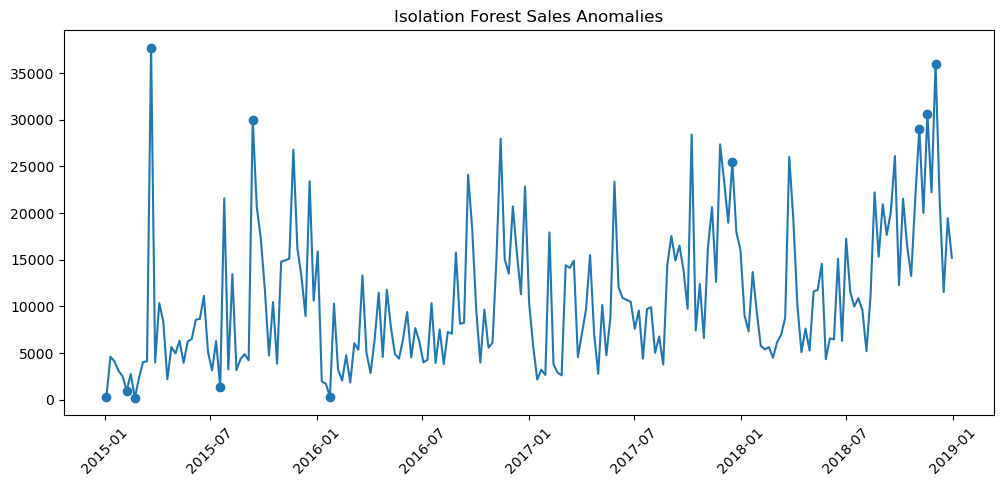

In [11]:
plt.figure(figsize=(12,5))


plt.plot(
    weekly_sales["Date"],
    weekly_sales["Sales"]
)


anomalies = weekly_sales[
    weekly_sales["IF_Label"]
    ==
    "Anomaly"
]


plt.scatter(
    anomalies["Date"],
    anomalies["Sales"]
)


plt.title(
    "Isolation Forest Sales Anomalies"
)


plt.xticks(rotation=45)
plt.savefig("charts/Isolation Forest Sales Anomalies.png")
plt.show()

# Z-Score

# Calculate Z-score

In [12]:
weekly_sales["Z_score"] = zscore(
    weekly_sales["Sales"]
)

## Define anomaly rule
Usually:

Z-score > 3
or
Z-score < -3

In [13]:
weekly_sales["Z_Anomaly"] = np.where(
    abs(weekly_sales["Z_score"]) > 3,
    "Anomaly",
    "Normal"
)

## Display Z-score anomalies

In [14]:
weekly_sales[
    weekly_sales["Z_Anomaly"]
    ==
    "Anomaly"
]

,Date,Sales,IF_Anomaly,IF_Label,Z_score,Z_Anomaly
11,2015-03-22,37703.665,-1,Anomaly,3.639852,Anomaly
204,2018-12-02,35998.900,-1,Anomaly,3.409032,Anomaly


## Compare Both Methods

In [15]:
comparison = weekly_sales[
    [
        "Date",
        "Sales",
        "IF_Label",
        "Z_Anomaly"
    ]
]


comparison.head()

,Date,Sales,IF_Label,Z_Anomaly
0,2015-01-04,304.508,Anomaly,Normal
1,2015-01-11,4619.108,Normal,Normal
2,2015-01-18,4130.533,Normal,Normal
3,2015-01-25,3092.544,Normal,Normal
4,2015-02-01,2527.914,Normal,Normal


## Count Agreement

In [16]:
pd.crosstab(
    weekly_sales["IF_Label"],
    weekly_sales["Z_Anomaly"]
)

Z_Anomaly,Anomaly,Normal
IF_Label,,
Anomaly,2,9
Normal,0,198


##  Observation

Isolation Forest and Z-score methods identify unusual sales periods.

Isolation Forest is machine learning based and can detect complex patterns,
while Z-score identifies points that are statistically far from the average.

Both methods provide similar anomaly periods, increasing confidence.

## Save Results

In [17]:
weekly_sales.to_csv(
    "models/anomaly_results.csv",
    index=False
)